# Chemometric Prediction of Coffee Bean Moisture Content using FT-NIR Spectroscopy

# 1. Environment Setup & Workspace Initialization

This section establishes the execution environment, configures repository dependencies, and initializes workspace directories.

In [1]:
import os
import sys
import re
import warnings
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter
from scipy.stats import chi2, f
from sklearn.cluster import KMeans
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut
from sklearn.ensemble import RandomForestRegressor
from google.colab import files, output

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    GITHUB_USER = "jeanpierredebs"
    REPO_NAME = "UniLaSalle"
    REPO_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"

    os.chdir('/content')

    if os.path.exists(REPO_NAME):
        if os.path.exists(os.path.join(REPO_NAME, REPO_NAME)) or not os.path.exists(os.path.join(REPO_NAME, '.git')):
            shutil.rmtree(REPO_NAME)

    if not os.path.exists(REPO_NAME):
        res = !git clone {REPO_URL}
        print(res)

    if os.path.exists(REPO_NAME):
        os.chdir(f'/content/{REPO_NAME}')
        if os.path.exists('requirements.txt'):
            !pip install -q -r requirements.txt
    else:
        raise FileNotFoundError(f"Failed to clone {REPO_URL}. Check if repository is PUBLIC.")

Path("outputs/figures").mkdir(parents=True, exist_ok=True)
Path("outputs/results").mkdir(parents=True, exist_ok=True)

print(f"Working directory successfully set to: {os.getcwd()}")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.max_open_warning": 0})

["Cloning into 'UniLaSalle'...", 'remote: Enumerating objects: 88, done.\x1b[K', 'remote: Counting objects:   1% (1/88)\x1b[K', 'remote: Counting objects:   2% (2/88)\x1b[K', 'remote: Counting objects:   3% (3/88)\x1b[K', 'remote: Counting objects:   4% (4/88)\x1b[K', 'remote: Counting objects:   5% (5/88)\x1b[K', 'remote: Counting objects:   6% (6/88)\x1b[K', 'remote: Counting objects:   7% (7/88)\x1b[K', 'remote: Counting objects:   9% (8/88)\x1b[K', 'remote: Counting objects:  10% (9/88)\x1b[K', 'remote: Counting objects:  11% (10/88)\x1b[K', 'remote: Counting objects:  12% (11/88)\x1b[K', 'remote: Counting objects:  13% (12/88)\x1b[K', 'remote: Counting objects:  14% (13/88)\x1b[K', 'remote: Counting objects:  15% (14/88)\x1b[K', 'remote: Counting objects:  17% (15/88)\x1b[K', 'remote: Counting objects:  18% (16/88)\x1b[K', 'remote: Counting objects:  19% (17/88)\x1b[K', 'remote: Counting objects:  20% (18/88)\x1b[K', 'remote: Counting objects:  21% (19/88)\x1b[K', 'remote: Countin

## 2. Data Loading & Spectral Preprocessing

This section locates the target FT-NIR dataset, parses the raw spectral channels, and converts reflectance values into absorbance units.

In [2]:
sample_id_col = "Source_Sample_Identifier_For_Parchment_Coffee_Drying_Monitoring"
target_col = "Authoritative_Moisture_Content_Wet_Basis_Percent"
filename = "Authoritative_FT_NIR_Parchment_Coffee_Moisture_Chemometric_Corpus_Curated_Derivative.csv"

candidate_paths = [
    Path(filename),
    Path("data") / filename,
    Path("..") / filename
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(f"Dataset not found: {filename}")

df = pd.read_csv(data_path)

metadata_cols = list(df.columns[:6])
raw_spectral_cols = list(df.columns[6:])

pairs = []
for col in raw_spectral_cols:
    m = re.search(r"(\d+)", col)
    if m:
        pairs.append((int(m.group(1)), col))

if not pairs:
    raise RuntimeError("No numeric wavenumbers found in spectral column names.")

pairs_sorted = sorted(pairs, key=lambda x: x[0], reverse=True)
wavenumbers = np.array([p[0] for p in pairs_sorted], dtype=int)
spectral_cols = [p[1] for p in pairs_sorted]

X_spectra = df[spectral_cols].to_numpy(dtype=float)
X_spectra = np.clip(X_spectra, 1e-5, 100.0)
X_spectra = np.log10(100.0 / X_spectra)

if sample_id_col not in df.columns:
    raise RuntimeError(f"Column '{sample_id_col}' not found in dataset.")

metadata_df = df[metadata_cols].copy()
if sample_id_col not in metadata_df.columns:
    metadata_df[sample_id_col] = df[sample_id_col]

metadata_ids = metadata_df[sample_id_col].fillna("").astype(str).to_numpy()
y_moisture = df[target_col].astype(float).to_numpy()

# 3. Exploratory Data Analysis & Quality Control Checks

This section executes initial data integrity audits, verifies spectral feature dimensions, and inspects the distribution of replicate scans per physical sample identifier.

Using wavenumber range 12000 to 4000 with 2001 points.
Total rows: 73, total columns: 2007
Total missing values: 0
Total duplicated rows: 0
Target range: min=8.5, max=52.4888532036



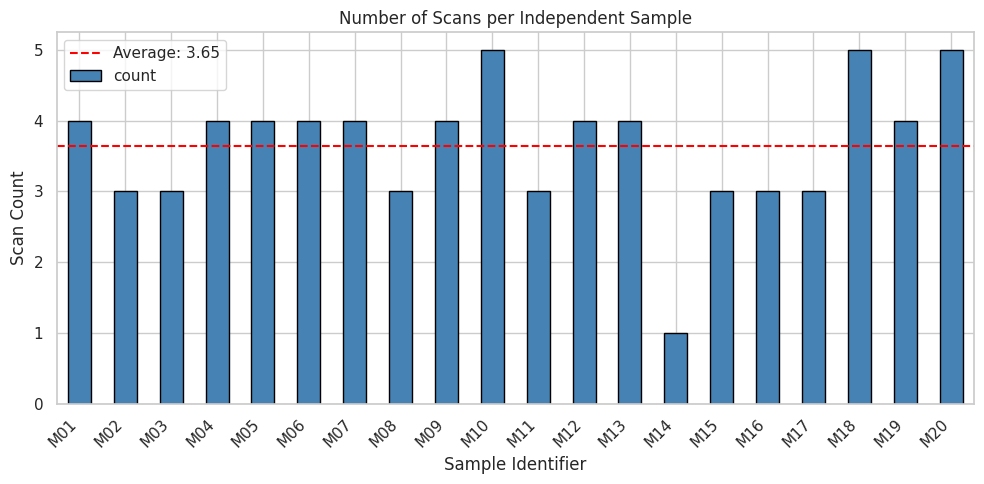

In [3]:
print(f"Using wavenumber range {wavenumbers.max()} to {wavenumbers.min()} with {len(wavenumbers)} points.")
print(f"Total rows: {df.shape[0]}, total columns: {df.shape[1]}")
print(f"Total missing values: {int(df.isna().sum().sum())}")
print(f"Total duplicated rows: {int(df.duplicated().sum())}")
print(f"Target range: min={y_moisture.min()}, max={y_moisture.max()}\n")

reps_per_sample = metadata_df[sample_id_col].astype(str).value_counts().sort_index()
fig = plt.figure(figsize=(10, 5))
reps_per_sample.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Number of Scans per Independent Sample")
plt.xlabel("Sample Identifier")
plt.ylabel("Scan Count")
plt.xticks(rotation=45, ha="right")
plt.axhline(reps_per_sample.mean(), color="red", linestyle="--",
            label=f"Average: {reps_per_sample.mean():.2f}")
plt.legend()
plt.tight_layout()
fig.savefig("outputs/figures/scans_per_sample.svg", format="svg", bbox_inches="tight")
plt.show()

## 4. Individual Sample Spectra and Mean Spectra

Generates multi-panel grid plots displaying the raw absorbance spectra for each unique sample, followed by a parallel set of plots showing the mean spectra with standard deviation shaded boundaries.

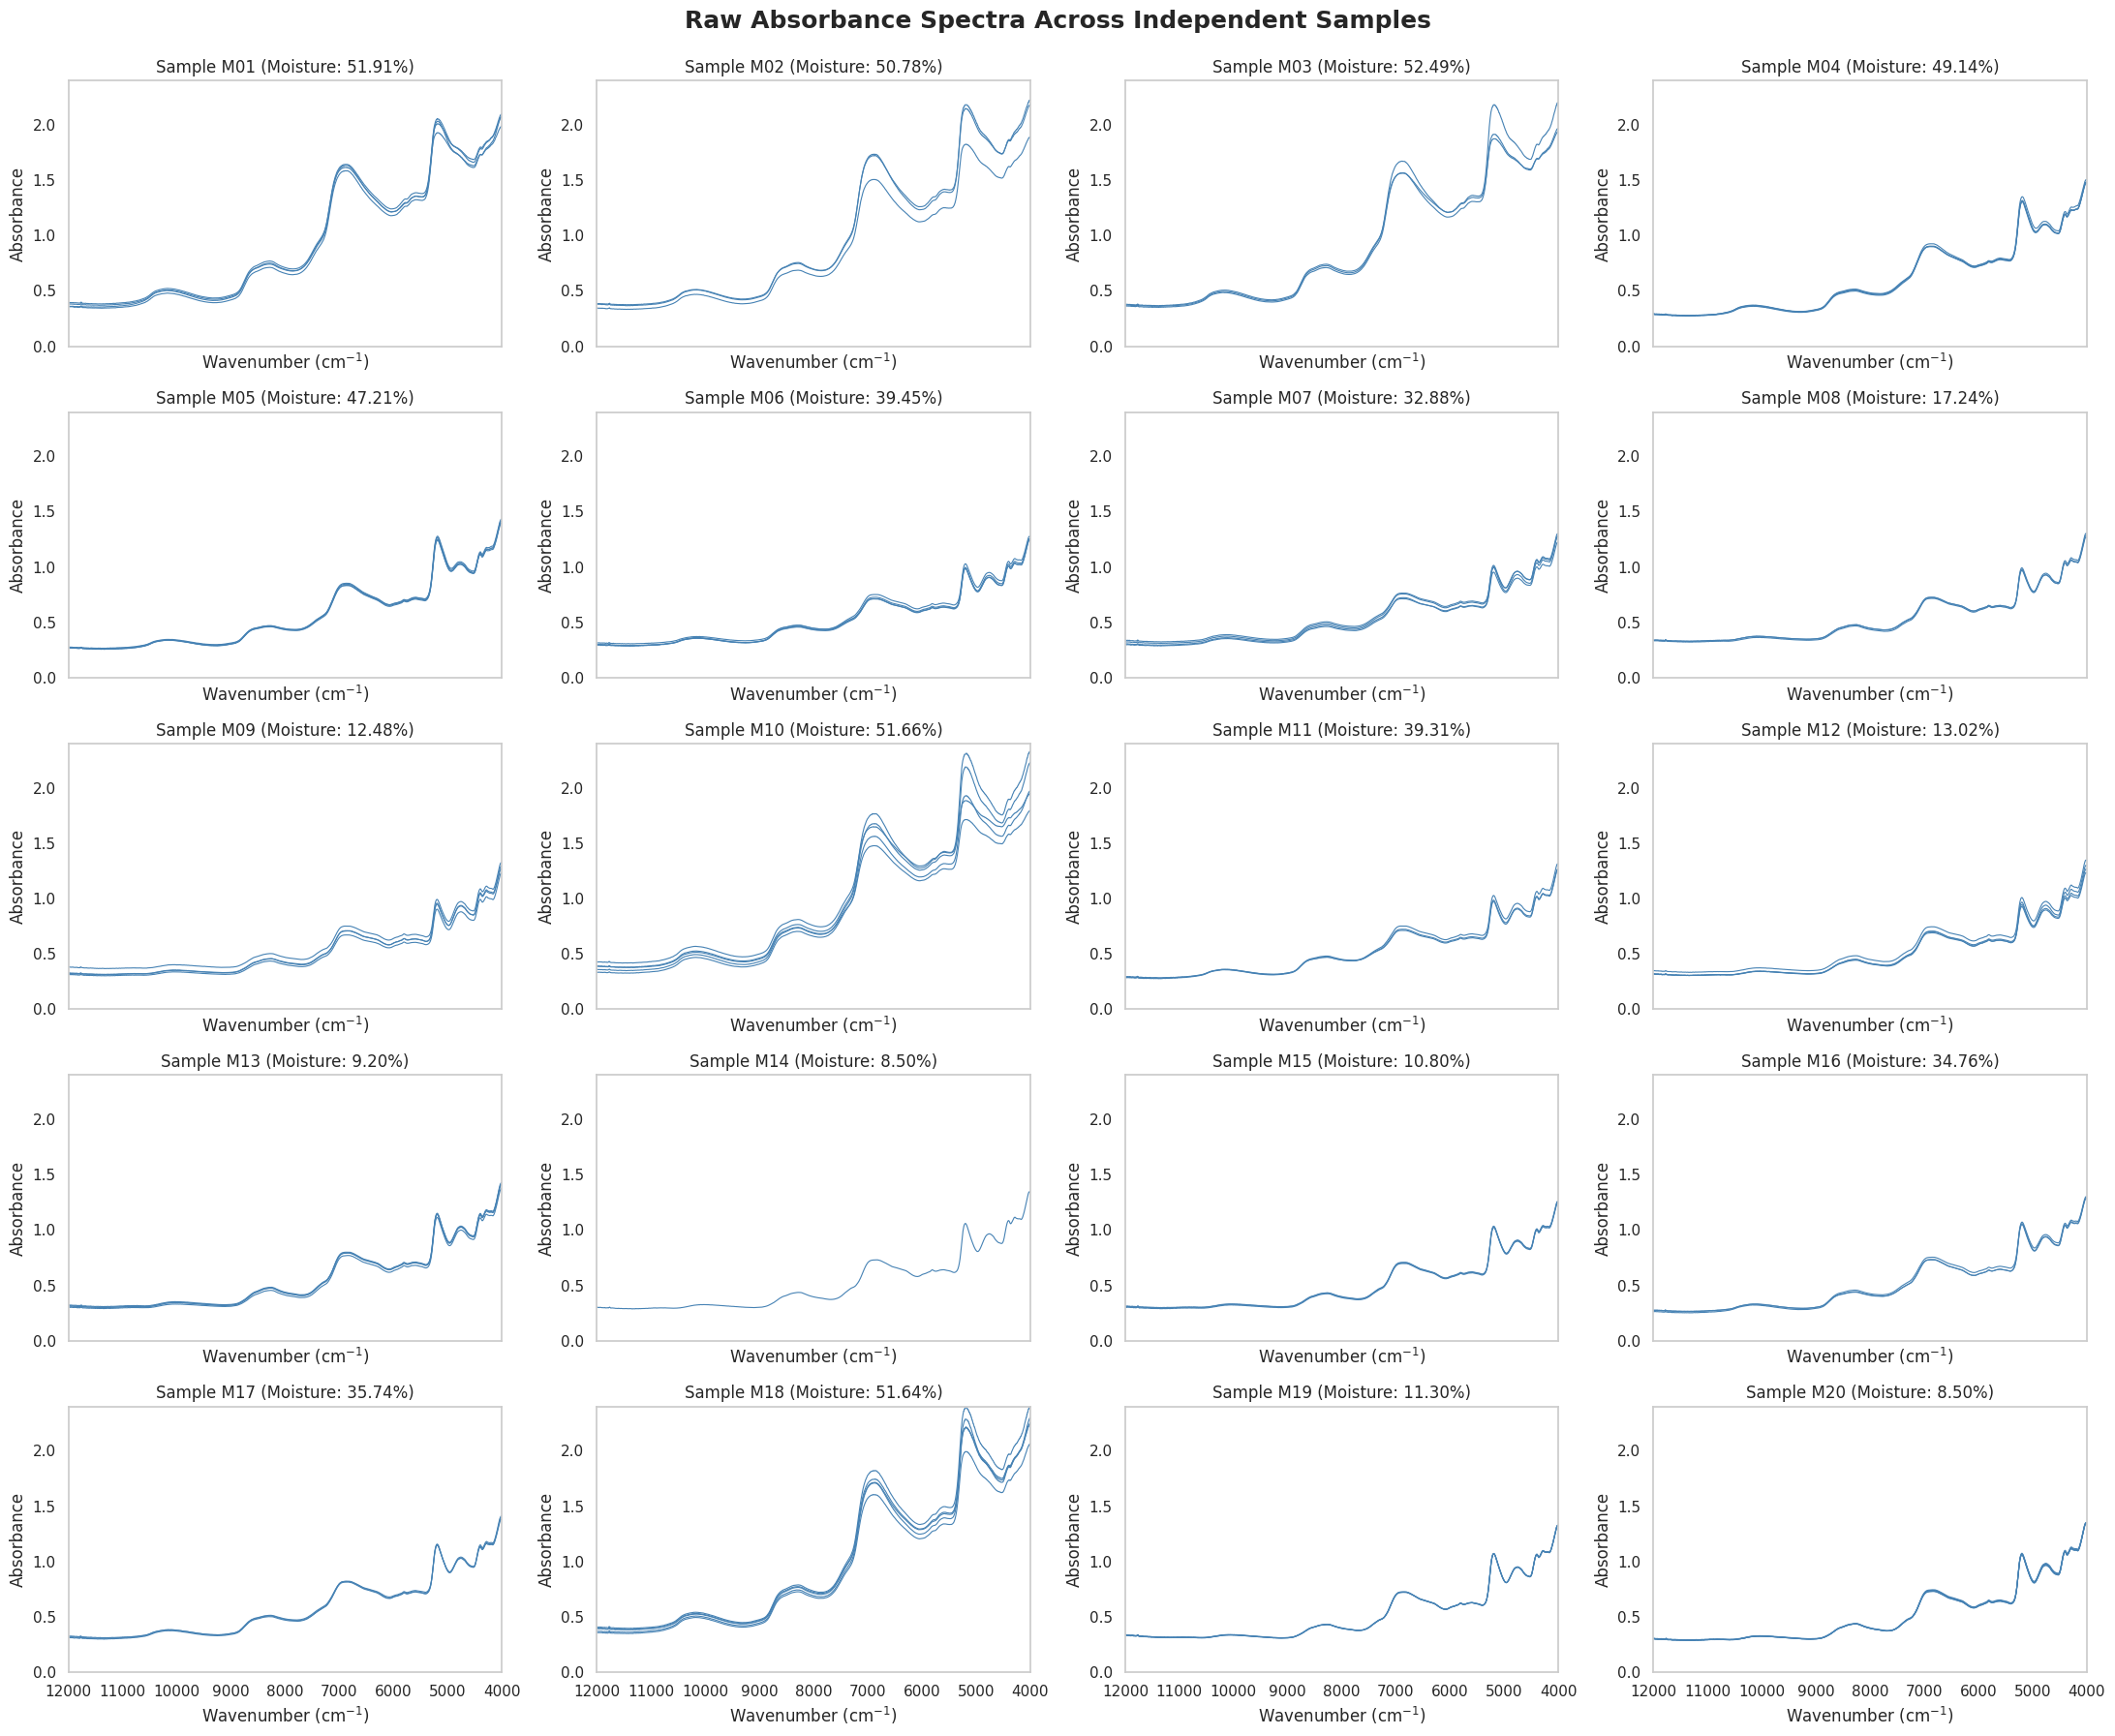

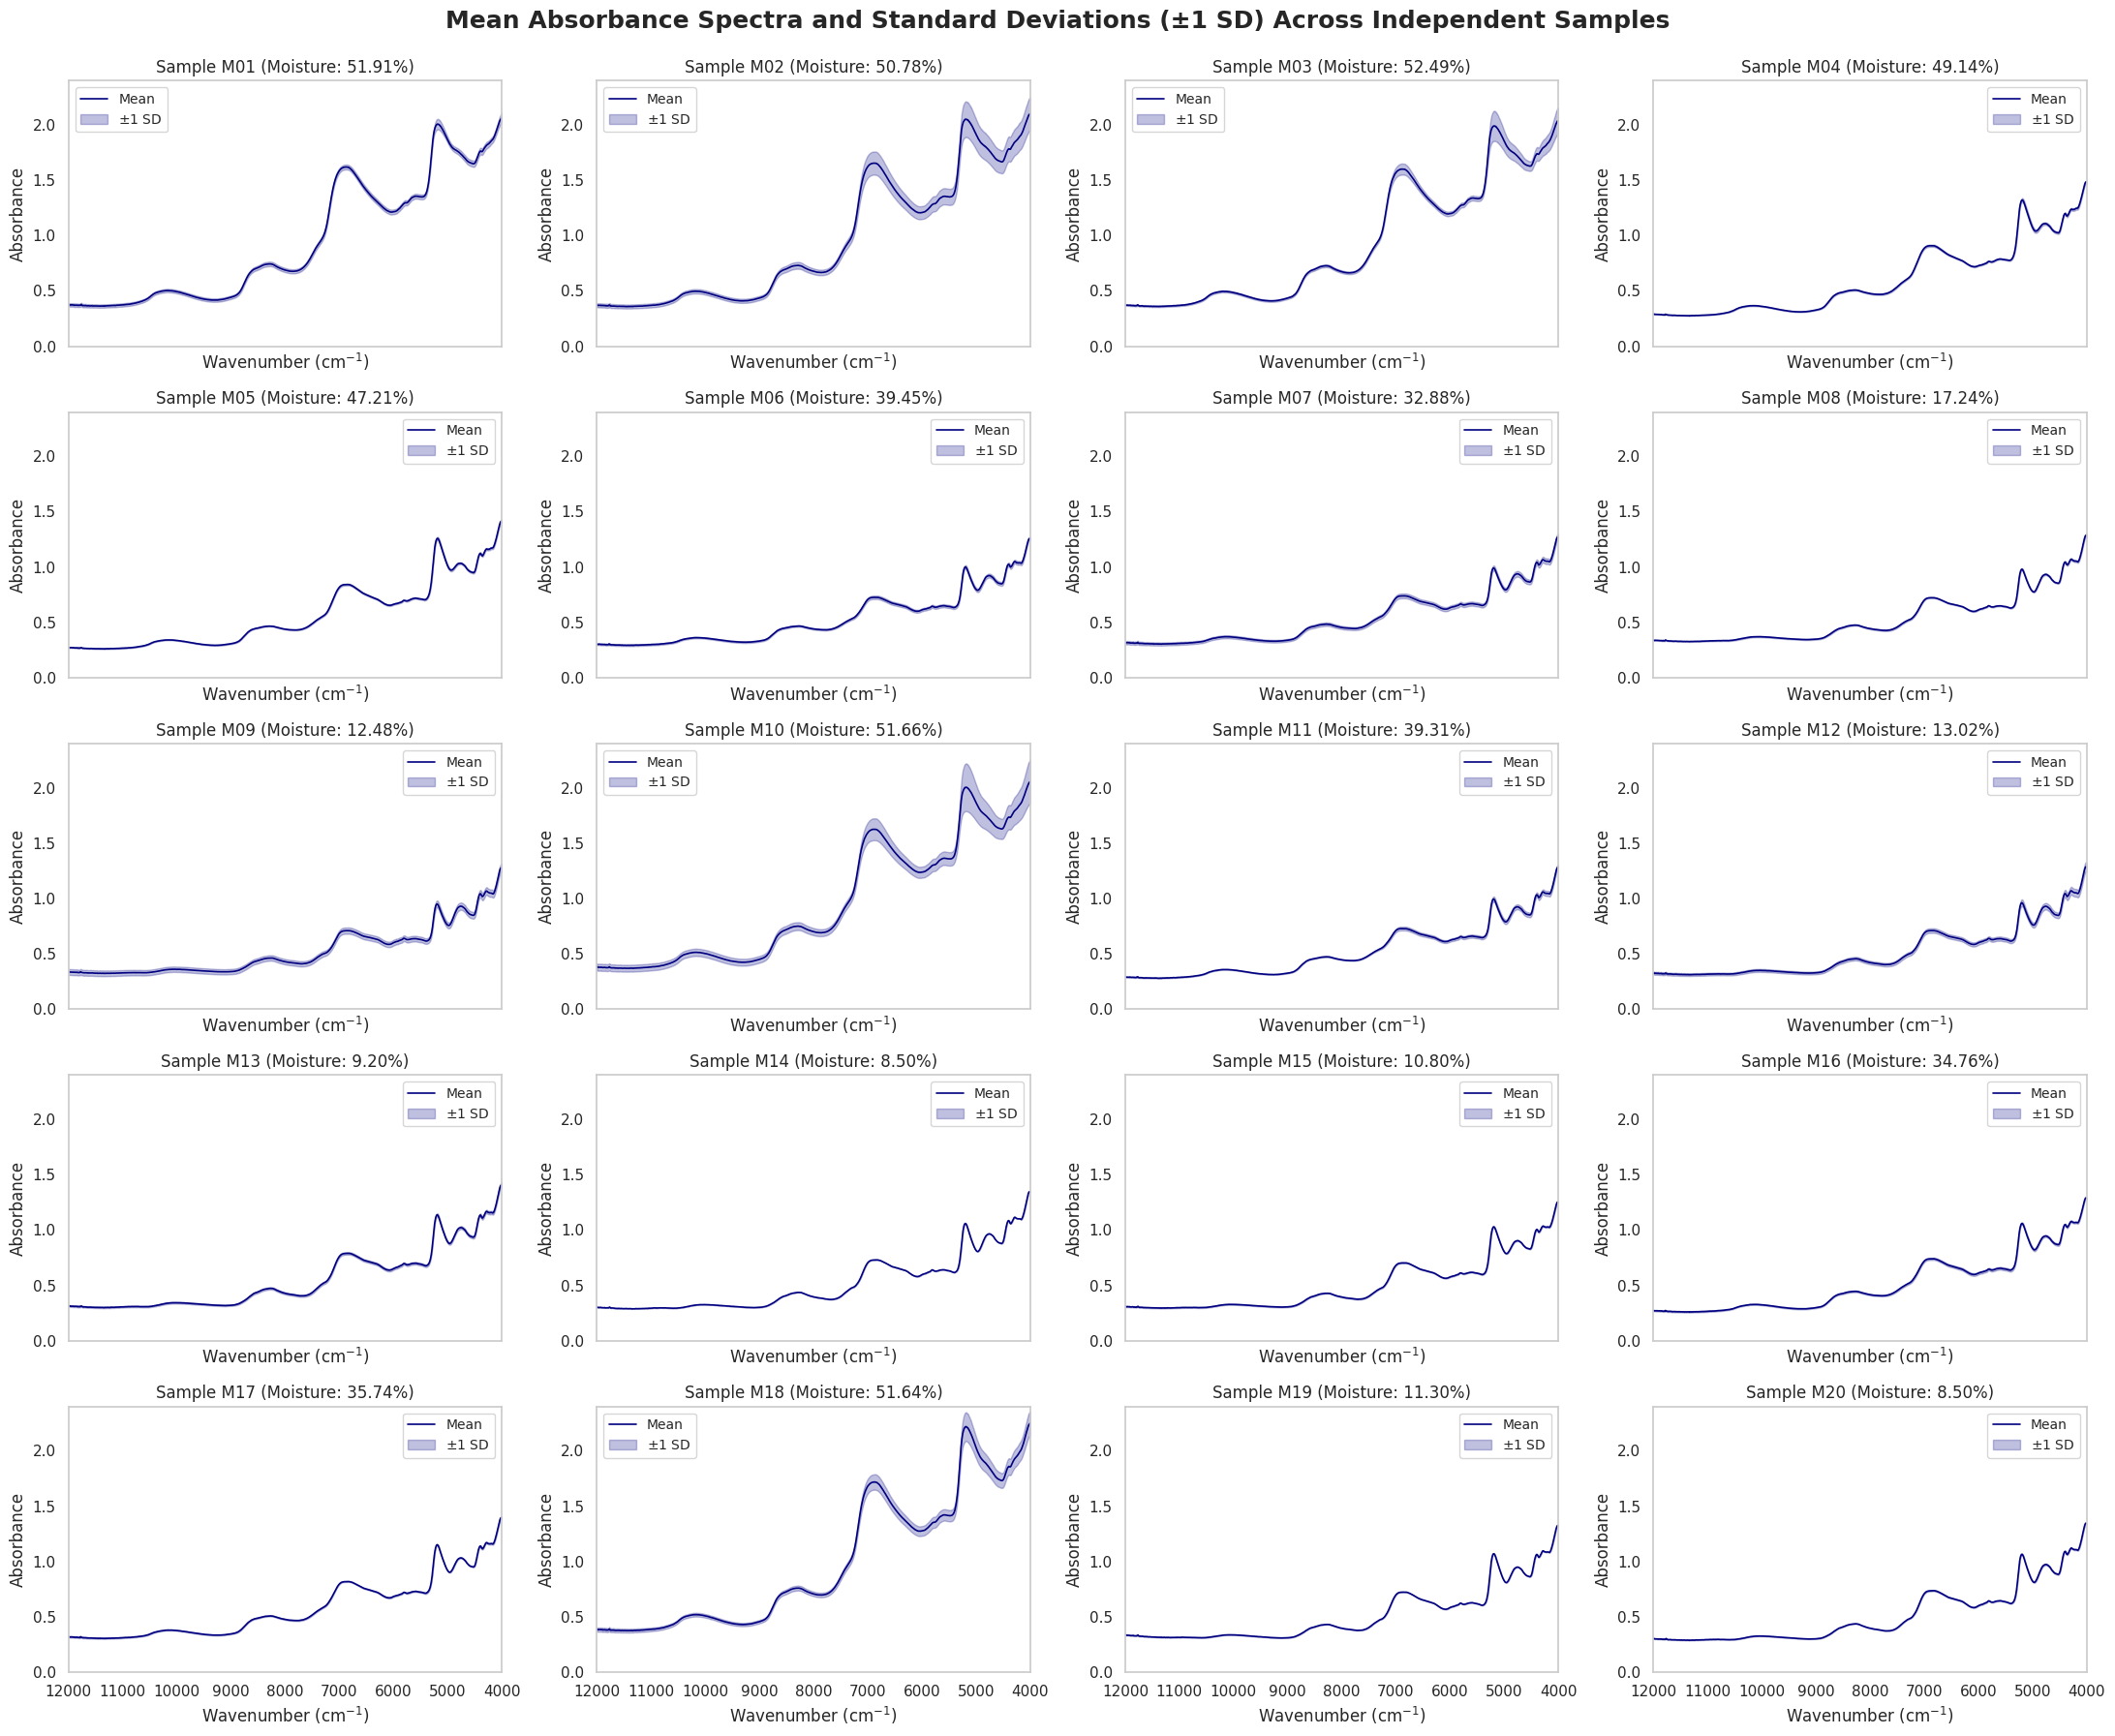

In [4]:
unique_sample_ids = np.unique(metadata_ids[metadata_ids != ""])
max_y = float(np.max(X_spectra))

fig, axes = plt.subplots(5, 4, figsize=(22, 18), sharex=True)
axes = axes.ravel()
for ax, sid in zip(axes, unique_sample_ids):
    mask = metadata_ids == sid
    spectra_subset = X_spectra[mask, :]
    mean_moisture = df.loc[mask, target_col].astype(float).mean()
    title = f"Sample {sid} (Moisture: {mean_moisture:.2f}%)" if not np.isnan(mean_moisture) else f"Sample {sid}"
    for row in spectra_subset:
        ax.plot(wavenumbers, row, color="steelblue", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel(r"Wavenumber (cm$^{-1}$)")
    ax.set_ylabel("Absorbance")
    ax.set_ylim(0, max_y)
    ax.set_xlim(wavenumbers.max(), wavenumbers.min())
    ax.grid(False)
for ax in axes[len(unique_sample_ids):]:
    ax.axis("off")
fig.suptitle("Raw Absorbance Spectra Across Independent Samples", fontsize=18, fontweight="bold", y=0.995)
plt.tight_layout()
fig.savefig("outputs/figures/sample_spectra.svg", format="svg", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(5, 4, figsize=(22, 18), sharex=True)
axes = axes.ravel()
for ax, sid in zip(axes, unique_sample_ids):
    mask = metadata_ids == sid
    spectra_subset = X_spectra[mask, :]
    if spectra_subset.size == 0:
        ax.set_title(f"{sid} (no data)")
        ax.axis("off")
        continue
    mean_moisture = df.loc[mask, target_col].astype(float).mean()
    title = f"Sample {sid} (Moisture: {mean_moisture:.2f}%)" if not np.isnan(mean_moisture) else f"Sample {sid}"
    mean_spectrum = spectra_subset.mean(axis=0)
    std_spectrum = spectra_subset.std(axis=0)
    ax.plot(wavenumbers, mean_spectrum, color="navy", linewidth=1.2, label="Mean")
    ax.fill_between(wavenumbers, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum,
                    color="navy", alpha=0.25, label=r"$\pm$1 SD")
    ax.set_title(title)
    ax.set_xlabel(r"Wavenumber (cm$^{-1}$)")
    ax.set_ylabel("Absorbance")
    ax.set_ylim(0, max_y)
    ax.set_xlim(wavenumbers.max(), wavenumbers.min())
    ax.grid(False)
    ax.legend(fontsize="small")
for ax in axes[len(unique_sample_ids):]:
    ax.axis("off")
fig.suptitle("Mean Absorbance Spectra and Standard Deviations (±1 SD) Across Independent Samples", fontsize=18, fontweight="bold", y=0.995)
plt.tight_layout()
fig.savefig("outputs/figures/mean_spectra_per_sample.svg", format="svg", bbox_inches="tight")
plt.show()

## 5. Target Distribution Analysis

Computes summary statistics (mean, median, standard deviation, and key percentiles) for the target moisture variable and plots its frequency histogram with a kernel density estimate and reference lines.

Descriptive statistics for target variable:
          count     mean  median      std  min      25%     50%      75%      max
moisture     73  32.2915  35.742  17.6321  8.5  12.4756  35.742  50.7786  52.4889 



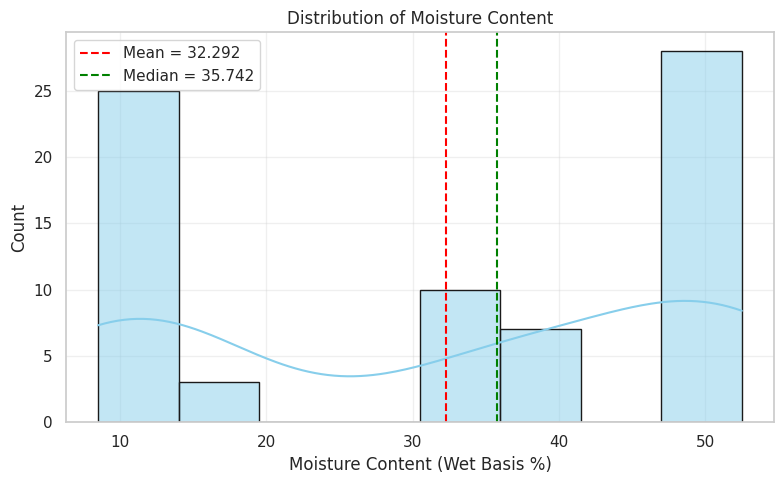

In [5]:
target = y_moisture.copy()
desc = pd.Series(target).describe()
median_val = float(np.median(target))
stats = pd.DataFrame({
    "count": int(desc["count"]), "mean": float(desc["mean"]),
    "median": median_val, "std": float(desc["std"]),
    "min": float(desc["min"]), "25%": float(desc["25%"]),
    "50%": float(desc["50%"]), "75%": float(desc["75%"]),
    "max": float(desc["max"]),
}, index=["moisture"])
print("Descriptive statistics for target variable:")
print(stats.round(4).to_string(),"\n")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(target, kde=True, ax=ax, color="skyblue", edgecolor="k")
mean_val = float(np.mean(target))
ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5,
           label=f"Mean = {mean_val:.3f}")
ax.axvline(median_val, color="green", linestyle="--", linewidth=1.5,
           label=f"Median = {median_val:.3f}")
ax.set_title("Distribution of Moisture Content")
ax.set_xlabel("Moisture Content (Wet Basis %)")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig("outputs/figures/moisture_distribution.svg", format="svg", bbox_inches="tight")
plt.show()

## 6. K-Means Moisture Clustering

Applies K-Means clustering ($k=3$) to the reference moisture values to categorize samples into Dry, Semi-dried, and Wet clusters, and plots their mean spectra with standard deviation shading.

Dry cluster center: 11.3971
Semi-dried cluster center: 36.3989
Wet cluster center: 50.6922
Dry samples: 28, Semi-dried samples: 17, Wet samples: 28



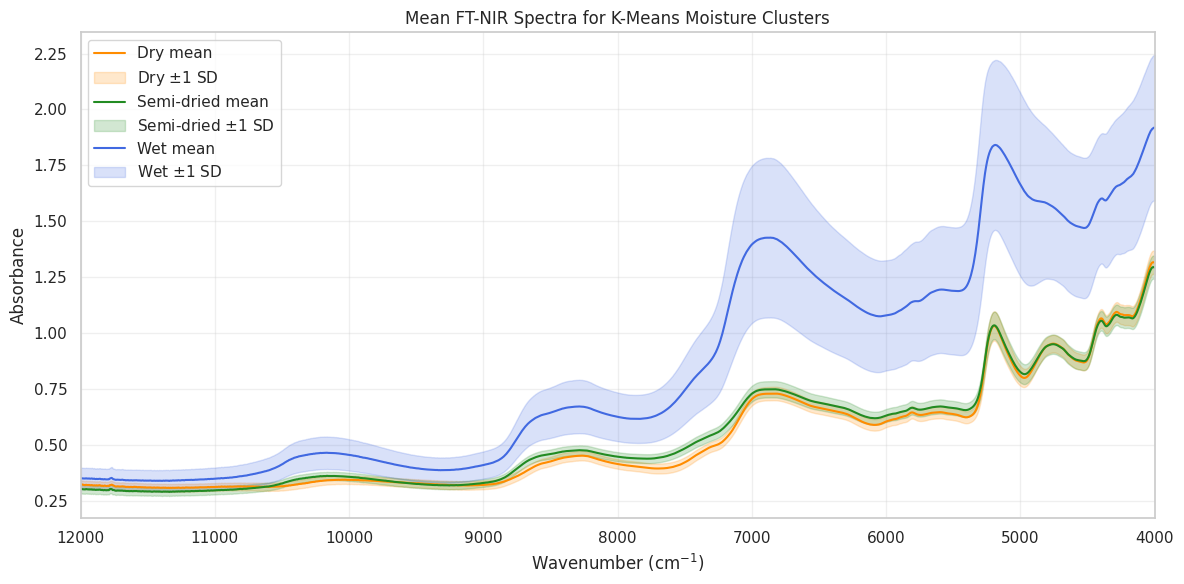

In [6]:
moisture_ref = target.reshape(-1, 1)
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(moisture_ref)
cluster_labels = kmeans.labels_
centers = kmeans.cluster_centers_.flatten()

sorted_cluster_indices = np.argsort(centers)
dry_label, mid_label, wet_label = sorted_cluster_indices

print(f"Dry cluster center: {centers[dry_label]:.4f}")
print(f"Semi-dried cluster center: {centers[mid_label]:.4f}")
print(f"Wet cluster center: {centers[wet_label]:.4f}")
print(f"Dry samples: {(cluster_labels == dry_label).sum()}, "
      f"Semi-dried samples: {(cluster_labels == mid_label).sum()}, "
      f"Wet samples: {(cluster_labels == wet_label).sum()}\n")

mean_dry, std_dry = X_spectra[cluster_labels == dry_label].mean(axis=0), X_spectra[cluster_labels == dry_label].std(axis=0)
mean_mid, std_mid = X_spectra[cluster_labels == mid_label].mean(axis=0), X_spectra[cluster_labels == mid_label].std(axis=0)
mean_wet, std_wet = X_spectra[cluster_labels == wet_label].mean(axis=0), X_spectra[cluster_labels == wet_label].std(axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
for mean, std, color, name in [(mean_dry, std_dry, "darkorange", "Dry"),
                                 (mean_mid, std_mid, "forestgreen", "Semi-dried"),
                                 (mean_wet, std_wet, "royalblue", "Wet")]:
    ax.plot(wavenumbers, mean, color=color, label=f"{name} mean")
    ax.fill_between(wavenumbers, mean - std, mean + std, color=color, alpha=0.2,
                    label=f"{name} $\\pm$1 SD")
ax.set_title("Mean FT-NIR Spectra for K-Means Moisture Clusters")
ax.set_xlabel(r"Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Absorbance")
ax.set_xlim(wavenumbers.max(), wavenumbers.min())
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig("outputs/figures/kmeans_three_moisture_clusters.svg", format="svg", bbox_inches="tight")
plt.show()

## 7. Preprocessing and Outlier Detection Functions

Defines helper functions for Standard Normal Variate (SNV) and Savitzky-Golay 1st derivative (SG1) transformations, PCA-based outlier detection using Hotelling's T2 and Q-residuals, and custom diagnostic plotting routines.

In [7]:
def apply_snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, ddof=0, keepdims=True)
    std[std == 0] = 1.0
    return (X - mean) / std


def apply_sg1(X, window_length=25, polyorder=2, wavenumbers=None):
    delta = np.mean(np.diff(wavenumbers)) if wavenumbers is not None else 1.0
    return savgol_filter(X, window_length=window_length, polyorder=polyorder,
                         deriv=1, delta=delta, axis=1)


def pca_outlier_detection(X, metadata_ids, y_moisture, n_max_components=20):
    n_samples, n_features = X.shape
    X_centered = X - X.mean(axis=0)
    cov = np.cov(X_centered, rowvar=False)
    inv_cov = np.linalg.pinv(cov)
    mahalanobis_dist = np.sum((X_centered @ inv_cov) * X_centered, axis=1)
    md_threshold = chi2.ppf(0.99, df=n_features)
    md_outliers = mahalanobis_dist > md_threshold

    n_comp = min(10, n_features)
    pca = PCA(n_components=n_comp)
    scores = pca.fit_transform(X)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    if cum_var[-1] < 0.99 and n_features > n_comp:
        n_comp = min(n_features, n_max_components)
        pca = PCA(n_components=n_comp)
        scores = pca.fit_transform(X)
        cum_var = np.cumsum(pca.explained_variance_ratio_)

    explained_vars = pca.explained_variance_
    T2 = np.sum((scores ** 2) / explained_vars, axis=1)
    T2_crit = (pca.n_components_ * (n_samples - 1) /
               (n_samples - pca.n_components_) *
               f.ppf(0.99, pca.n_components_, n_samples - pca.n_components_))

    X_recon = pca.inverse_transform(scores)
    residuals = X - X_recon
    Q_residuals = np.sum(residuals ** 2, axis=1)
    Q_crit = np.quantile(Q_residuals, 0.99)

    T2_outliers = T2 > T2_crit
    Q_outliers = Q_residuals > Q_crit
    structural_outliers = np.where(T2_outliers | Q_outliers)[0]

    print(f"PCA components used: {pca.n_components_}")
    print(f"Cumulative variance: {cum_var[-1]:.4f}")
    print(f"Hotelling's T² 99% limit: {T2_crit:.2f}")
    print(f"Q-Residual 99% limit: {Q_crit:.2f}")

    outlier_type = np.where(
        T2_outliers & Q_outliers, "T2+Q",
        np.where(T2_outliers, "T2",
                 np.where(Q_outliers, "Q", "Normal")))

    summary_df = pd.DataFrame({
        "Sample_ID": metadata_ids,
        "Scan_Index": [list(metadata_ids[:i + 1]).count(sid) for i, sid in enumerate(metadata_ids)],
        "Moisture": y_moisture,
        "Mahalanobis": md_outliers,
        "Hotelling_T2": T2_outliers,
        "Q_Residual": Q_outliers,
        "Outlier_Type": outlier_type,
    })

    outlier_rows = summary_df[summary_df[["Mahalanobis", "Hotelling_T2", "Q_Residual"]].any(axis=1)]
    if len(outlier_rows) > 0:
        print(f"Structural outliers (T² or Q): {structural_outliers.tolist()}")
        print(outlier_rows.to_string())

    return {
        "T2": T2, "T2_crit": T2_crit,
        "Q_residuals": Q_residuals, "Q_crit": Q_crit,
        "structural_outliers": structural_outliers,
        "summary_df": summary_df,
    }


def plot_outlier_diagnostics(T2, Q_residuals, T2_crit, Q_crit, filename,
                              T2_prev=None, Q_prev=None, title_suffix=""):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(T2, Q_residuals, s=30, alpha=0.7, color="teal", label="All Samples")
    if T2_prev is not None and Q_prev is not None:
        ax.scatter(T2_prev, Q_prev, s=120, color="red", marker="X", zorder=5,
                   label="Previous Outlier")
    ax.axvline(T2_crit, color="red", linestyle="--", label=f"T$^2$ 99% limit ({T2_crit:.2f})")
    ax.axhline(Q_crit, color="purple", linestyle="--", label=f"Q-residual 99% limit ({Q_crit:.2f})")
    ax.set_xlabel("Hotelling's $T^2$")
    ax.set_ylabel("Q-Residual (DModX)")
    ax.set_title(f"PCA Outlier Diagnostic{title_suffix}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(filename, format="svg", bbox_inches="tight")
    plt.show()


def plot_color_coded_spectra(ax, X, wavenumbers, moisture_values, cmap, norm):
    for i in range(X.shape[0]):
        ax.plot(wavenumbers, X[i, :], color=cmap(norm(moisture_values[i])),
                alpha=0.7, linewidth=0.8)


def add_colorbar(fig, cmap, norm, label, position=None):
    if position is None:
        position = [0.92, 0.15, 0.015, 0.7]
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.add_axes(position)
    fig.colorbar(sm, cax=cax, orientation="vertical", label=label)

## 8. Raw Spectra PCA Outlier Detection

Executes PCA-based outlier detection on the raw absorbance spectra using Hotelling's T2 and Q-residual limits, saves the diagnostic plot, and identifies the initial outlier index for tracking.


--- PCA Outlier Detection (Raw Spectra) ---
PCA components used: 10
Cumulative variance: 1.0000
Hotelling's T² 99% limit: 29.90
Q-Residual 99% limit: 0.01
Structural outliers (T² or Q): [37]
   Sample_ID  Scan_Index  Moisture  Mahalanobis  Hotelling_T2  Q_Residual Outlier_Type
37       M10           5  51.66365        False          True        True         T2+Q


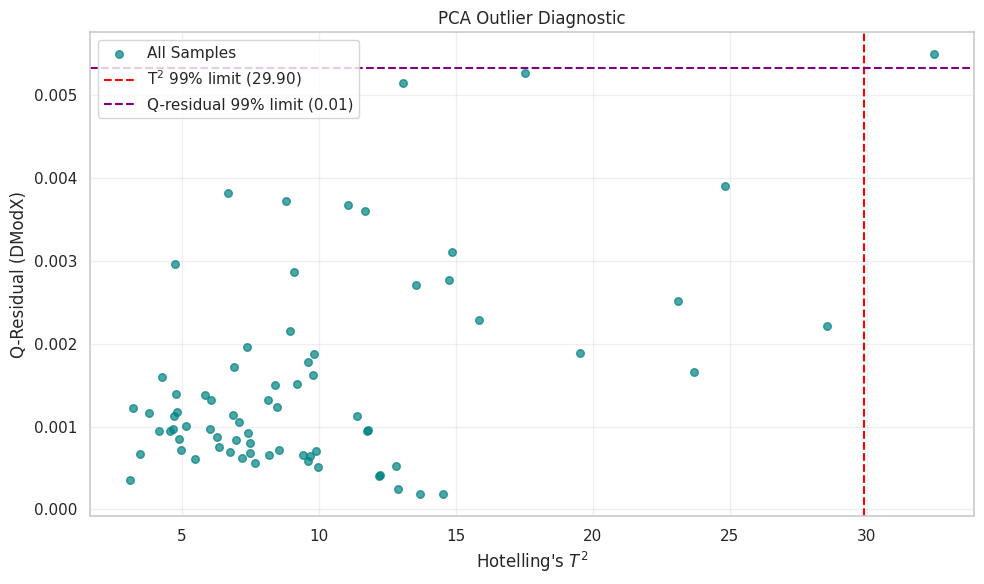

In [8]:
print("\n--- PCA Outlier Detection (Raw Spectra) ---")
result_raw = pca_outlier_detection(X_spectra, metadata_ids, y_moisture)
plot_outlier_diagnostics(
    result_raw["T2"], result_raw["Q_residuals"],
    result_raw["T2_crit"], result_raw["Q_crit"],
    "outputs/figures/pca_outlier_diagnostics.svg")

previous_outlier_idx = (result_raw["structural_outliers"][0]
                        if len(result_raw["structural_outliers"]) > 0 else None)

## 9. Raw vs. Raw + SG1 Spectral Comparison

Applies Savitzky-Golay 1st derivative (SG1) preprocessing to the raw spectra and generates a side-by-side comparison plot against the raw spectra, color-coded by moisture content.

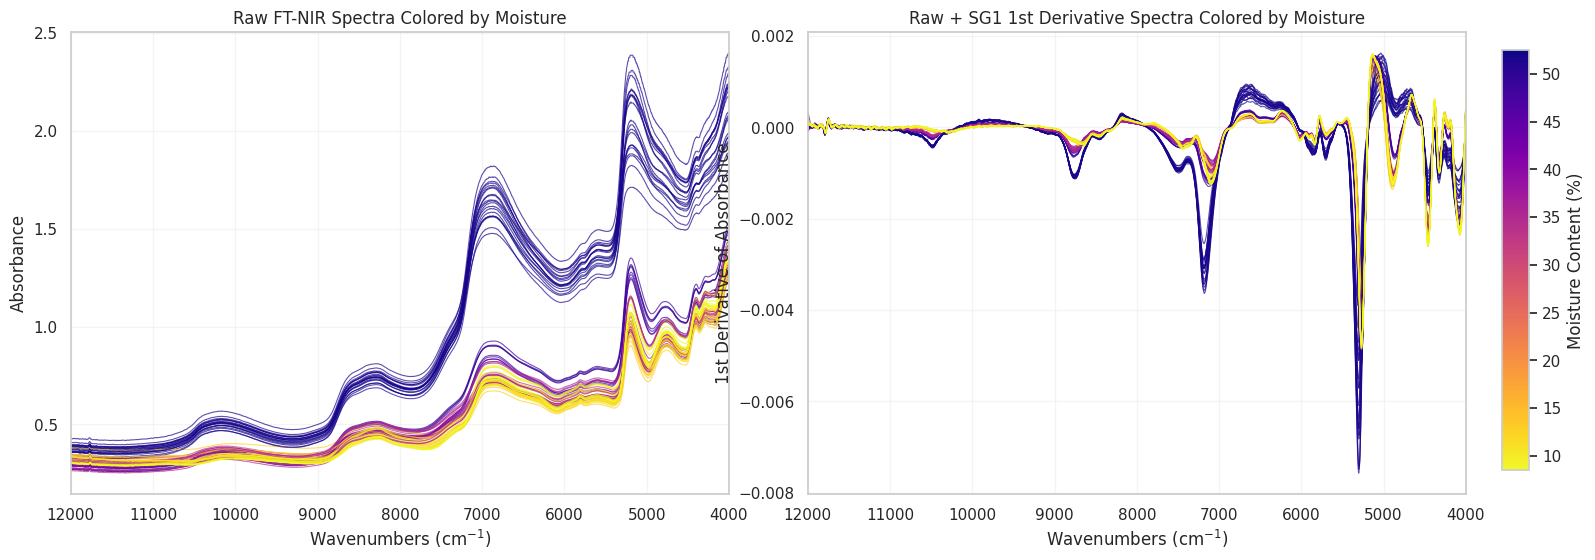

In [9]:
X_raw_sg1 = apply_sg1(X_spectra, window_length=15, wavenumbers=wavenumbers)

norm_moisture = plt.Normalize(vmin=y_moisture.min(), vmax=y_moisture.max())
cmap_moisture = plt.get_cmap("plasma_r")

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.12)
ax_raw = fig.add_subplot(gs[0])
ax_sg1 = fig.add_subplot(gs[1])

plot_color_coded_spectra(ax_raw, X_spectra, wavenumbers, y_moisture, cmap_moisture, norm_moisture)
ax_raw.set_title("Raw FT-NIR Spectra Colored by Moisture")
ax_raw.set_xlabel(r"Wavenumbers (cm$^{-1}$)")
ax_raw.set_ylabel("Absorbance")
ax_raw.set_xlim(wavenumbers.max(), wavenumbers.min())
ax_raw.grid(alpha=0.2)

plot_color_coded_spectra(ax_sg1, X_raw_sg1, wavenumbers, y_moisture, cmap_moisture, norm_moisture)
ax_sg1.set_title("Raw + SG1 1st Derivative Spectra Colored by Moisture")
ax_sg1.set_xlabel(r"Wavenumbers (cm$^{-1}$)")
ax_sg1.set_ylabel("1st Derivative of Absorbance")
ax_sg1.set_xlim(wavenumbers.max(), wavenumbers.min())
ax_sg1.grid(alpha=0.2)

add_colorbar(fig, cmap_moisture, norm_moisture, "Moisture Content (%)")
fig.savefig("outputs/figures/raw_vs_raw_sg1_spectra.svg", format="svg", bbox_inches="tight")
plt.show()

## 10. Raw vs. SNV Spectral Comparison

Applies Standard Normal Variate (SNV) preprocessing to remove scattering effects and generates a side-by-side comparison plot against the raw spectra, color-coded by moisture content.

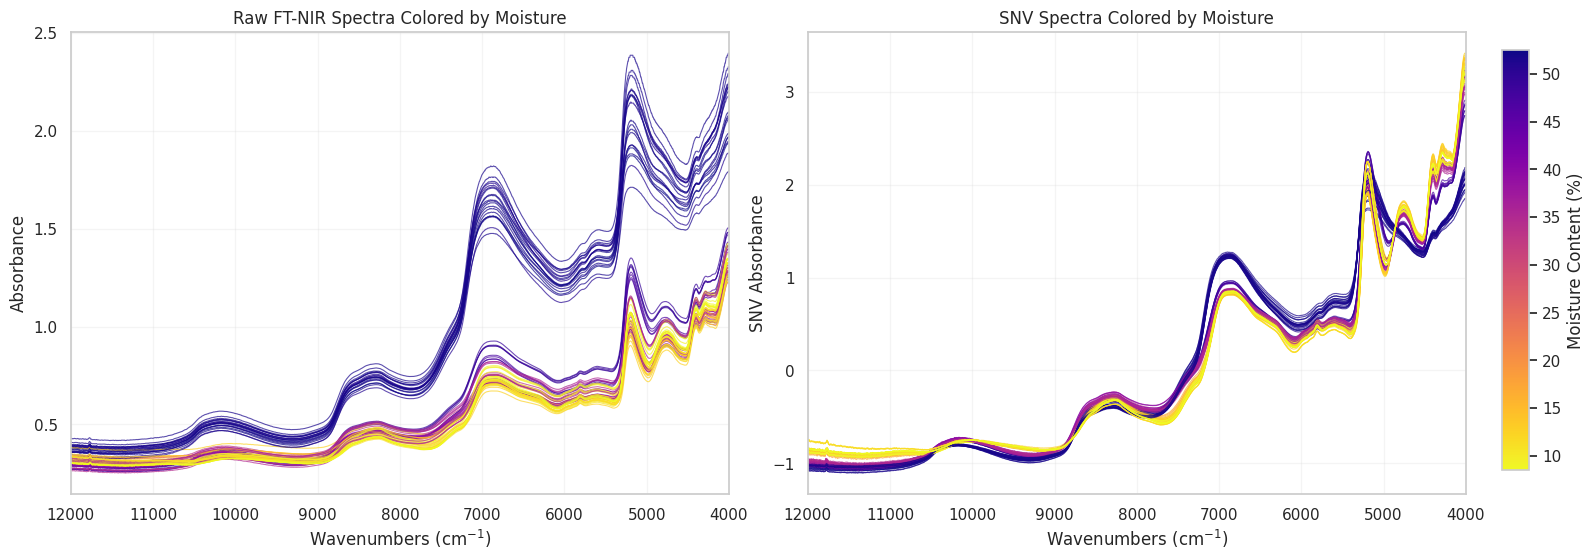

In [10]:
X_snv = apply_snv(X_spectra)

norm_moisture = plt.Normalize(vmin=y_moisture.min(), vmax=y_moisture.max())
cmap_moisture = plt.get_cmap("plasma_r")

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.12)
ax_raw = fig.add_subplot(gs[0])
ax_snv = fig.add_subplot(gs[1])

plot_color_coded_spectra(ax_raw, X_spectra, wavenumbers, y_moisture, cmap_moisture, norm_moisture)
ax_raw.set_title("Raw FT-NIR Spectra Colored by Moisture")
ax_raw.set_xlabel(r"Wavenumbers (cm$^{-1}$)")
ax_raw.set_ylabel("Absorbance")
ax_raw.set_xlim(wavenumbers.max(), wavenumbers.min())
ax_raw.grid(alpha=0.2)

plot_color_coded_spectra(ax_snv, X_snv, wavenumbers, y_moisture, cmap_moisture, norm_moisture)
ax_snv.set_title("SNV Spectra Colored by Moisture")
ax_snv.set_xlabel(r"Wavenumbers (cm$^{-1}$)")
ax_snv.set_ylabel("SNV Absorbance")
ax_snv.set_xlim(wavenumbers.max(), wavenumbers.min())
ax_snv.grid(alpha=0.2)

add_colorbar(fig, cmap_moisture, norm_moisture, "Moisture Content (%)")
fig.savefig("outputs/figures/raw_vs_SNV_spectra.svg", format="svg", bbox_inches="tight")
plt.show()

## 11. SG Window Length Comparison

Evaluates and plots the effect of varying Savitzky-Golay derivative window lengths (15, 25, and 35) on the SNV-transformed spectra.

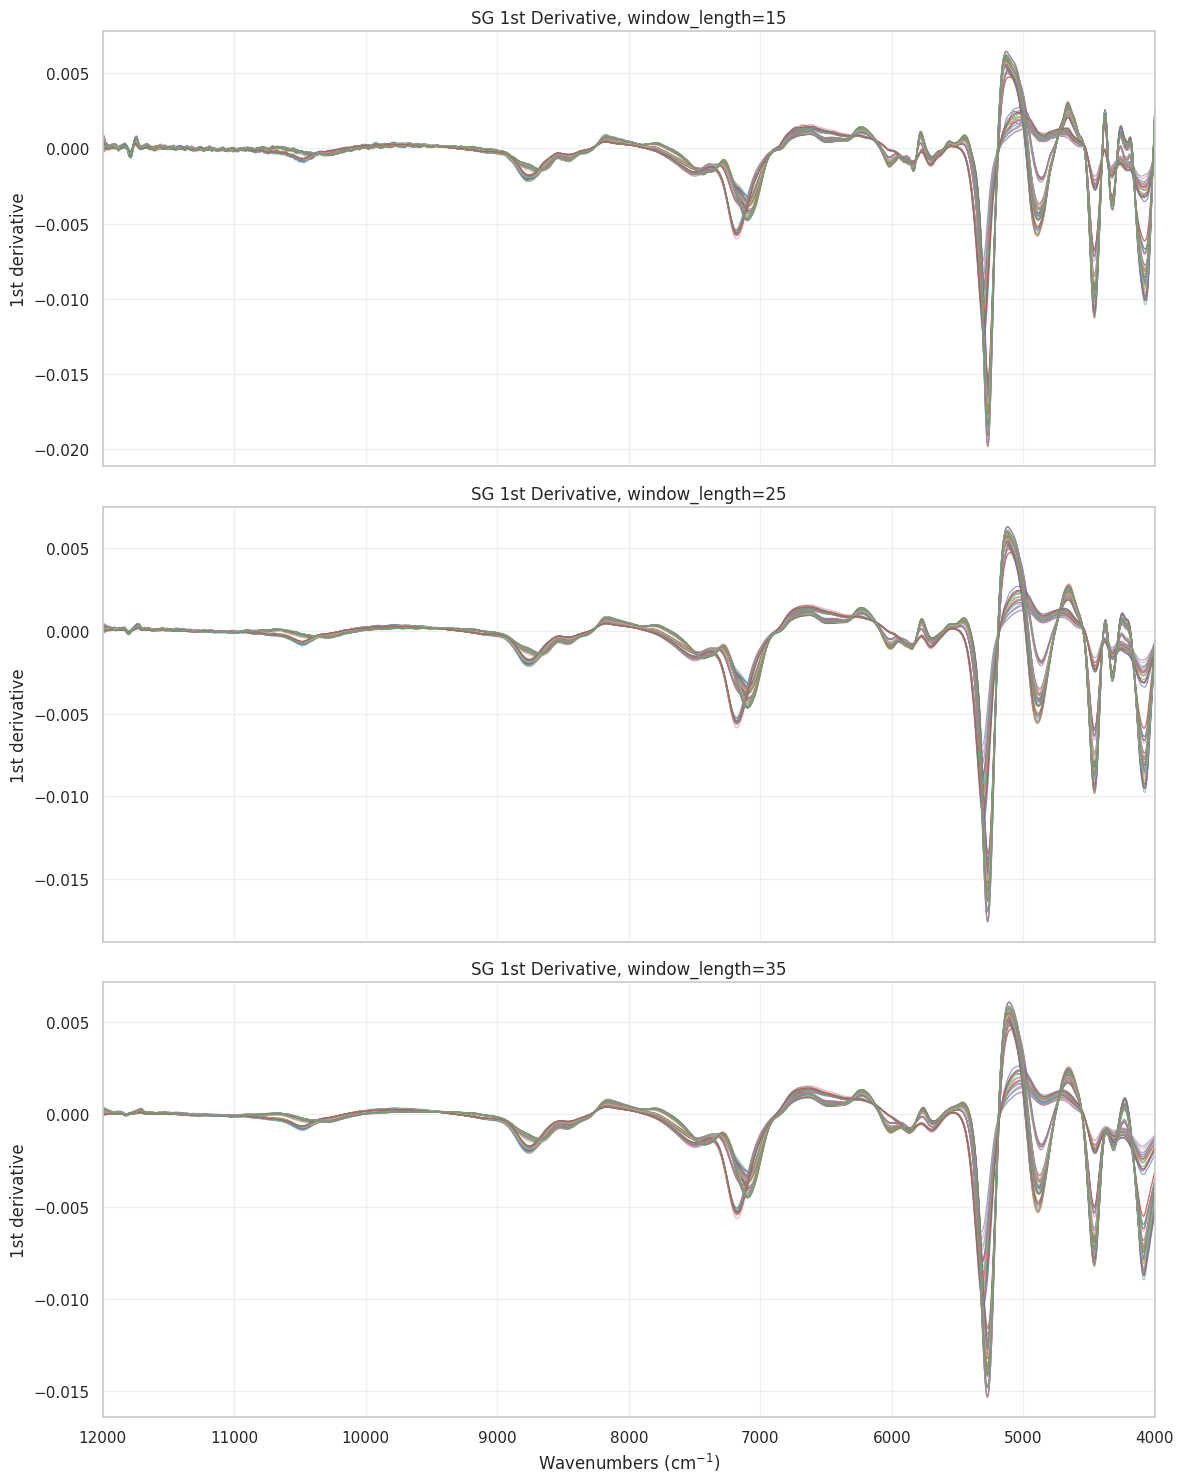

In [11]:
window_lengths = [15, 25, 35]
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
for ax, wl in zip(axes, window_lengths):
    X_temp = apply_sg1(X_snv, window_length=wl, wavenumbers=wavenumbers)
    for i in range(X_temp.shape[0]):
        ax.plot(wavenumbers, X_temp[i, :], alpha=0.7, linewidth=0.8)
    ax.set_title(f"SG 1st Derivative, window_length={wl}")
    ax.set_ylabel("1st derivative")
    ax.set_xlim(wavenumbers.max(), wavenumbers.min())
    ax.grid(alpha=0.3)
axes[-1].set_xlabel(r"Wavenumbers (cm$^{-1}$)")
plt.tight_layout()
fig.savefig("outputs/figures/sg_derivative_comparison.svg", format="svg", bbox_inches="tight")
plt.show()

## 12. SNV and SNV + SG1 Spectral Comparison

Applies the Savitzky-Golay 1st derivative filter (window length 25) to the SNV-corrected spectra and generates a stacked comparative plot against the standard SNV spectra, color-coded by moisture content.

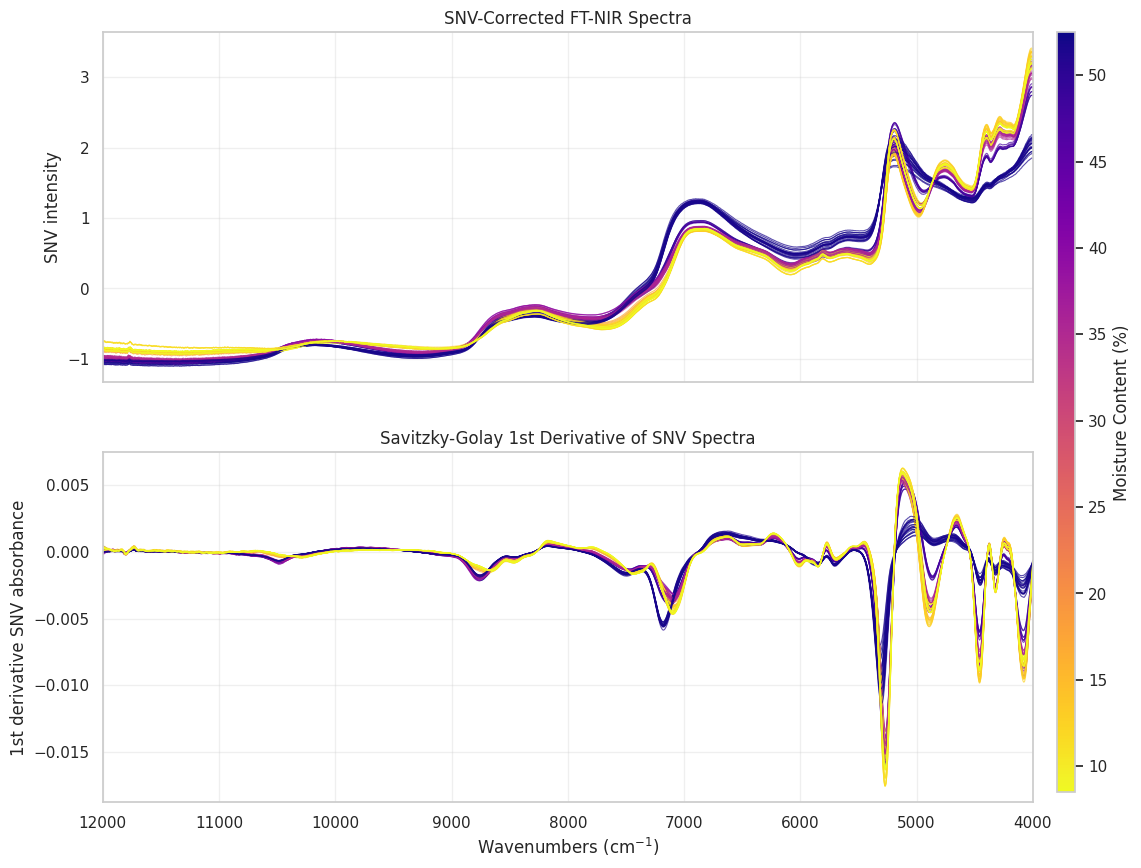

In [12]:
X_snv_sg1 = apply_sg1(X_snv, window_length=25, wavenumbers=wavenumbers)

colors = cmap_moisture(norm_moisture(y_moisture))
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
for i in range(X_snv.shape[0]):
    axes[0].plot(wavenumbers, X_snv[i, :], color=colors[i], alpha=0.7, linewidth=0.8)
axes[0].set_title("SNV-Corrected FT-NIR Spectra")
axes[0].set_ylabel("SNV intensity")
axes[0].set_xlim(wavenumbers.max(), wavenumbers.min())

for i in range(X_snv_sg1.shape[0]):
    axes[1].plot(wavenumbers, X_snv_sg1[i, :], color=colors[i], alpha=0.7, linewidth=0.8)
axes[1].set_title("Savitzky-Golay 1st Derivative of SNV Spectra")
axes[1].set_xlabel(r"Wavenumbers (cm$^{-1}$)")
axes[1].set_ylabel("1st derivative SNV absorbance")
axes[1].set_xlim(wavenumbers.max(), wavenumbers.min())

for ax in axes:
    ax.grid(alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap_moisture, norm=norm_moisture)
sm.set_array([])
cax = fig.add_axes([0.92, 0.12, 0.015, 0.76])
fig.colorbar(sm, cax=cax, orientation="vertical", label="Moisture Content (%)")
fig.savefig("outputs/figures/snv_sg1_spectra.svg", format="svg", bbox_inches="tight")
plt.show()

## 13. SNV + SG1 Outlier Detection and Analysis

Performs PCA-based outlier detection on the SNV + SG1 preprocessed spectra, evaluates Hotelling's T2 and Q-residual limits with respect to previously flagged samples, and generates diagnostic and comparative overlay plots for any detected outliers.

--- PCA Outlier Detection (SNV + SG1) ---
PCA components used: 10
Cumulative variance: 0.9994
Hotelling's T² 99% limit: 29.90
Q-Residual 99% limit: 0.00
Structural outliers (T² or Q): [6]
  Sample_ID  Scan_Index   Moisture  Mahalanobis  Hotelling_T2  Q_Residual Outlier_Type
6       M02           3  50.778576        False         False        True            Q


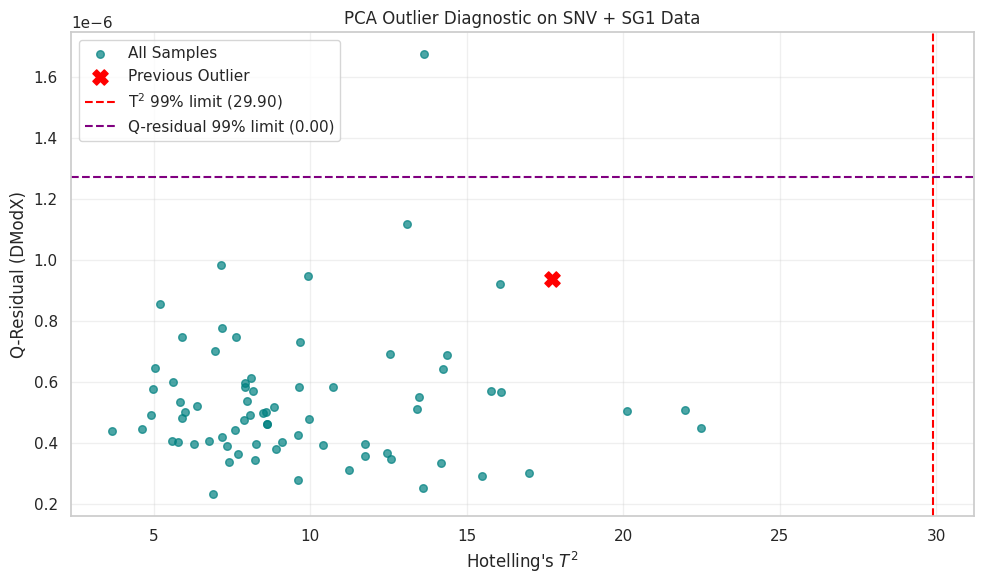

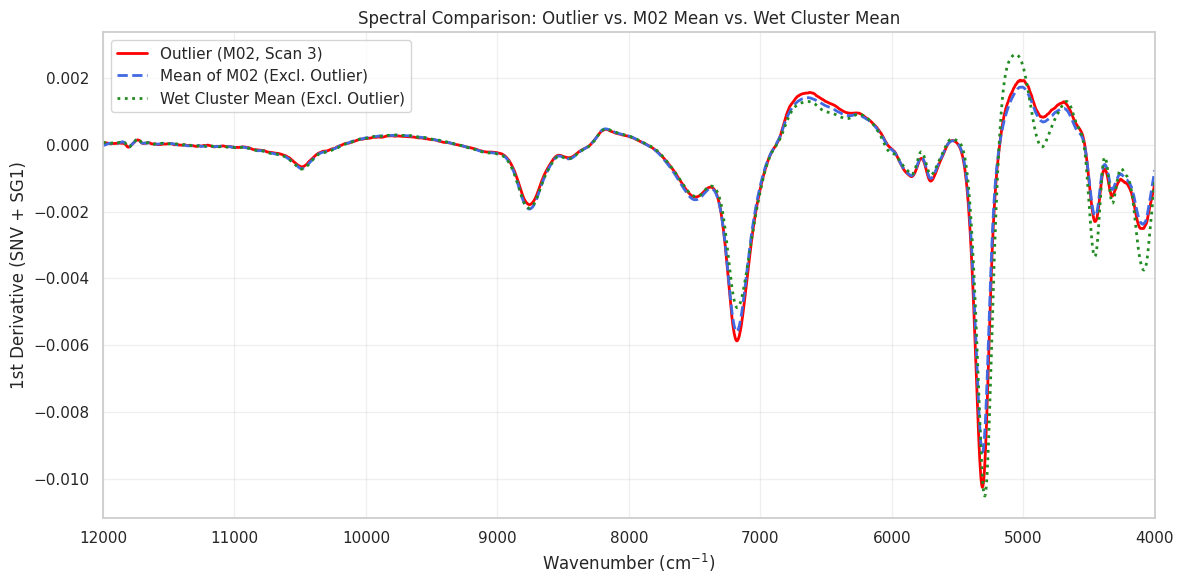

In [13]:
print("--- PCA Outlier Detection (SNV + SG1) ---")
result_snv_sg1 = pca_outlier_detection(X_snv_sg1, metadata_ids, y_moisture)

if previous_outlier_idx is not None:
    T2_prev = result_snv_sg1["T2"][previous_outlier_idx]
    Q_prev = result_snv_sg1["Q_residuals"][previous_outlier_idx]
else:
    T2_prev = Q_prev = None

plot_outlier_diagnostics(
    result_snv_sg1["T2"], result_snv_sg1["Q_residuals"],
    result_snv_sg1["T2_crit"], result_snv_sg1["Q_crit"],
    "outputs/figures/pca_outlier_diagnostics_snv_sg1.svg",
    T2_prev=T2_prev, Q_prev=Q_prev,
    title_suffix=" on SNV + SG1 Data")

outliers = result_snv_sg1["structural_outliers"]
if len(outliers) > 0:
    new_idx = outliers[np.argmax(result_snv_sg1["Q_residuals"][outliers])]
    target_sid = metadata_ids[new_idx]
    target_scan = result_snv_sg1["summary_df"].loc[new_idx, "Scan_Index"]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(wavenumbers, X_snv_sg1.T, color="lightgray", alpha=0.3, zorder=1)
    mean_all = X_snv_sg1.mean(axis=0)
    ax.plot(wavenumbers, mean_all, color="black", linestyle="--", linewidth=2,
            label="Mean (All Spectra)", zorder=2)

    sample_idx = np.where(metadata_ids == target_sid)[0]
    clean_idx = sample_idx[sample_idx != new_idx]
    if len(clean_idx) > 0:
        mean_clean = X_snv_sg1[clean_idx].mean(axis=0)
        ax.plot(wavenumbers, mean_clean, color="blue", linewidth=2,
                label=f"Mean (Sample {target_sid}, excluding outlier)", zorder=3)

    ax.plot(wavenumbers, X_snv_sg1[new_idx], color="red", linewidth=2,
            label=f"Outlier (Sample {target_sid}, Scan {target_scan})", zorder=4)
    ax.set_xlabel(r"Wavenumbers (cm$^{-1}$)")
    ax.set_ylabel("1st Derivative (SNV + SG1)")
    ax.set_title(f"SNV + SG1 Outlier Analysis (Sample {target_sid}, Scan {target_scan})")
    ax.set_xlim(wavenumbers.max(), wavenumbers.min())
    handles, legend_labels = ax.get_legend_handles_labels()
    handles.insert(0, Line2D([0], [0], color="lightgray", lw=2))
    legend_labels.insert(0, "All SNV + SG1 Spectra")
    ax.legend(handles, legend_labels)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig("outputs/figures/snv_sg1_outlier_overlay.svg", format="svg", bbox_inches="tight")
    plt.close()

    outlier_idx = new_idx
    outlier_sid = str(metadata_ids[outlier_idx])
    scan_count = list(metadata_ids[:outlier_idx + 1]).count(outlier_sid)

    target_cluster = cluster_labels[outlier_idx]
    cluster_name = {dry_label: "Dry", mid_label: "Semi-dried", wet_label: "Wet"}.get(target_cluster, "Unknown")

    cluster_mask = cluster_labels == target_cluster
    sid_mask = metadata_ids == outlier_sid

    clean_cluster = np.where(cluster_mask)[0]
    clean_cluster = clean_cluster[clean_cluster != outlier_idx]
    clean_sid = np.where(sid_mask)[0]
    clean_sid = clean_sid[clean_sid != outlier_idx]

    cluster_mean = X_snv_sg1[clean_cluster].mean(axis=0) if len(clean_cluster) > 0 else None
    sid_mean = X_snv_sg1[clean_sid].mean(axis=0) if len(clean_sid) > 0 else None

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(wavenumbers, X_snv_sg1[outlier_idx], color="red", linewidth=2,
        label=f"Outlier ({outlier_sid}, Scan {scan_count})")
    if sid_mean is not None:
        ax.plot(wavenumbers, sid_mean, color="royalblue", linestyle="--", linewidth=2,
            label=f"Mean of {outlier_sid} (Excl. Outlier)")
    if cluster_mean is not None:
        ax.plot(wavenumbers, cluster_mean, color="forestgreen", linestyle=":", linewidth=2,
            label=f"{cluster_name} Cluster Mean (Excl. Outlier)")
    ax.set_title(f"Spectral Comparison: Outlier vs. {outlier_sid} Mean vs. {cluster_name} Cluster Mean")
    ax.set_xlabel(r"Wavenumber (cm$^{-1}$)")
    ax.set_ylabel("1st Derivative (SNV + SG1)")
    ax.set_xlim(wavenumbers.max(), wavenumbers.min())
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig("outputs/figures/outlier_cluster_comparison.svg", format="svg", bbox_inches="tight")
    plt.show()

else:
    print("No outliers detected in the SNV + SG1 data.")


# 14. Cluster Spectra Comparison (SNV + SG1)

Computes and plots the mean and standard deviation bands for each moisture cluster for the SNV + SG1 preprocessed spectra.

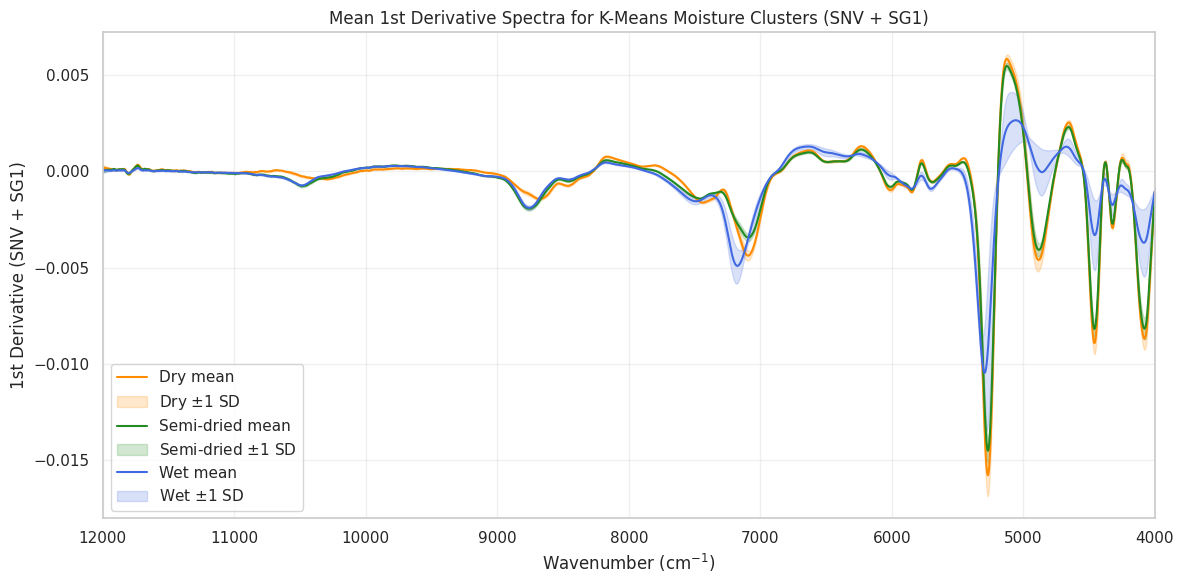

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

cluster_configs = [
    (dry_label, "darkorange", "Dry"),
    (mid_label, "forestgreen", "Semi-dried"),
    (wet_label, "royalblue", "Wet")
]
for clus_idx, color, name in cluster_configs:
    clus_mask = (cluster_labels == clus_idx)
    data_subset = X_snv_sg1[clus_mask]

    mean_val = data_subset.mean(axis=0)
    std_val = data_subset.std(axis=0)

    ax.plot(wavenumbers, mean_val, color=color, label=f"{name} mean")
    ax.fill_between(wavenumbers, mean_val - std_val, mean_val + std_val, color=color, alpha=0.2,
                    label=f"{name} $\pm$1 SD")
ax.set_title("Mean 1st Derivative Spectra for K-Means Moisture Clusters (SNV + SG1)")
ax.set_xlabel(r"Wavenumber (cm$^{-1}$)")
ax.set_ylabel("1st Derivative (SNV + SG1)")
ax.set_xlim(wavenumbers.max(), wavenumbers.min())
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig("outputs/figures/all_clusters_comparison_corrected.svg", format="svg", bbox_inches="tight")
plt.show()

## 15. Train-Test Split (Group-Aware)

Splits the modeling dataset using a group-aware shuffle split based on sample identifiers to ensure independent test groups, outputting dataset sizes and group distributions.

In [15]:
X_model = X_snv_sg1
y_model = y_moisture
groups = metadata_ids

splitter = GroupShuffleSplit(n_splits=1, train_size=0.75, test_size=0.25, random_state=0)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))

X_train, X_test = X_model[train_idx], X_model[test_idx]
y_train, y_test = y_model[train_idx], y_model[test_idx]
groups_train = groups[train_idx]
groups_test = groups[test_idx]

print(f"\nTrain: {len(train_idx)} samples, {np.unique(groups_train).size} groups")
print(f"Test:  {len(test_idx)} samples, {np.unique(groups_test).size} groups")
print(f"Train sample IDs: {np.unique(groups_train)}")
print(f"Test sample IDs:  {np.unique(groups_test)}")


Train: 54 samples, 15 groups
Test:  19 samples, 5 groups
Train sample IDs: ['M01' 'M03' 'M04' 'M05' 'M06' 'M07' 'M08' 'M10' 'M12' 'M13' 'M14' 'M15'
 'M16' 'M17' 'M18']
Test sample IDs:  ['M02' 'M09' 'M11' 'M19' 'M20']


## 16. PLS Model Optimization and Training

Performs Leave-One-Group-Out cross-validation across a range of PLS components, determines the optimal and elbow-selected component counts based on RMSECV, plots the complexity curve, and trains the final PLS regression model on the training data.


PLS optimal components: 9
PLS selected components (elbow): 3
Minimum RMSECV: 1.3063
Selected RMSECV: 1.6146


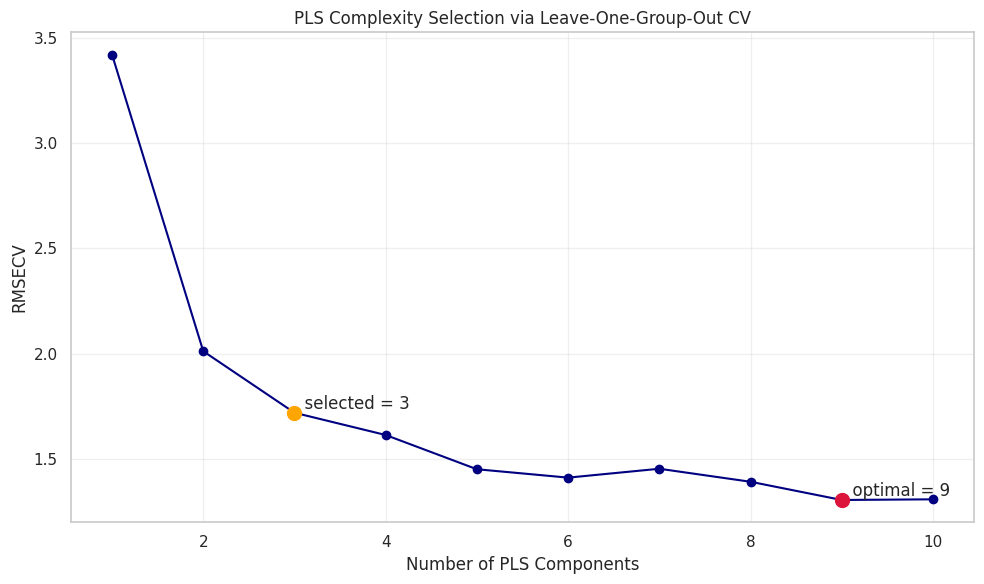

In [16]:
logo = LeaveOneGroupOut()
components_range = range(1, 11)
rmsecv = []
for n_comp in components_range:
    fold_errors = []
    for tr_idx, val_idx in logo.split(X_train, y_train, groups_train):
        model = PLSRegression(n_components=n_comp)
        model.fit(X_train[tr_idx], y_train[tr_idx])
        y_pred = model.predict(X_train[val_idx])
        fold_errors.append(np.sqrt(mean_squared_error(y_train[val_idx], y_pred)))
    rmsecv.append(np.mean(fold_errors))

rmsecv = np.array(rmsecv)
optimal_components = components_range[np.argmin(rmsecv)]

threshold = 0.10
selected_components = 1
for i in range(1, len(rmsecv)):
    rel_imp = (rmsecv[i - 1] - rmsecv[i]) / rmsecv[i - 1]
    if rel_imp < threshold:
        selected_components = i
        break
    selected_components = i + 1
selected_rmsecv = rmsecv[selected_components - 1]

print(f"\nPLS optimal components: {optimal_components}")
print(f"PLS selected components (elbow): {selected_components}")
print(f"Minimum RMSECV: {rmsecv[np.argmin(rmsecv)]:.4f}")
print(f"Selected RMSECV: {rmsecv[selected_components]:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(components_range, rmsecv, marker="o", linestyle="-", color="navy")
ax.scatter([optimal_components], [rmsecv[optimal_components - 1]], color="crimson", s=100, zorder=5)
ax.text(optimal_components, rmsecv[optimal_components - 1],
        f"  optimal = {optimal_components}", va="bottom", ha="left")
ax.scatter([selected_components], [selected_rmsecv], color="orange", s=100, zorder=5)
ax.text(selected_components, selected_rmsecv,
        f"  selected = {selected_components}", va="bottom", ha="left")
ax.set_xlabel("Number of PLS Components")
ax.set_ylabel("RMSECV")
ax.set_title("PLS Complexity Selection via Leave-One-Group-Out CV")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig("outputs/figures/pls_complexity_selection.svg", format="svg", bbox_inches="tight")
plt.show()

pls_final = PLSRegression(n_components=selected_components)
pls_final.fit(X_train, y_train)
y_pred_pls = pls_final.predict(X_test).squeeze()
y_test_flat = np.asarray(y_test).squeeze()

## 17. PLS Model Evaluation and Diagnostics

Computes standard test set evaluation metrics (RMSE, MAE, R², and bias) for the trained PLS model, saves the results and metrics to CSV, and generates a multi-panel diagnostic plot showing measured versus predicted values, residuals, and absolute errors.

--- PLS Test Performance ---
Latent Variables: 3
RMSECV: 1.7203
RMSE: 2.1998, 
MAE: 1.7530, 
R²: 0.9820, 
Bias: 1.0683


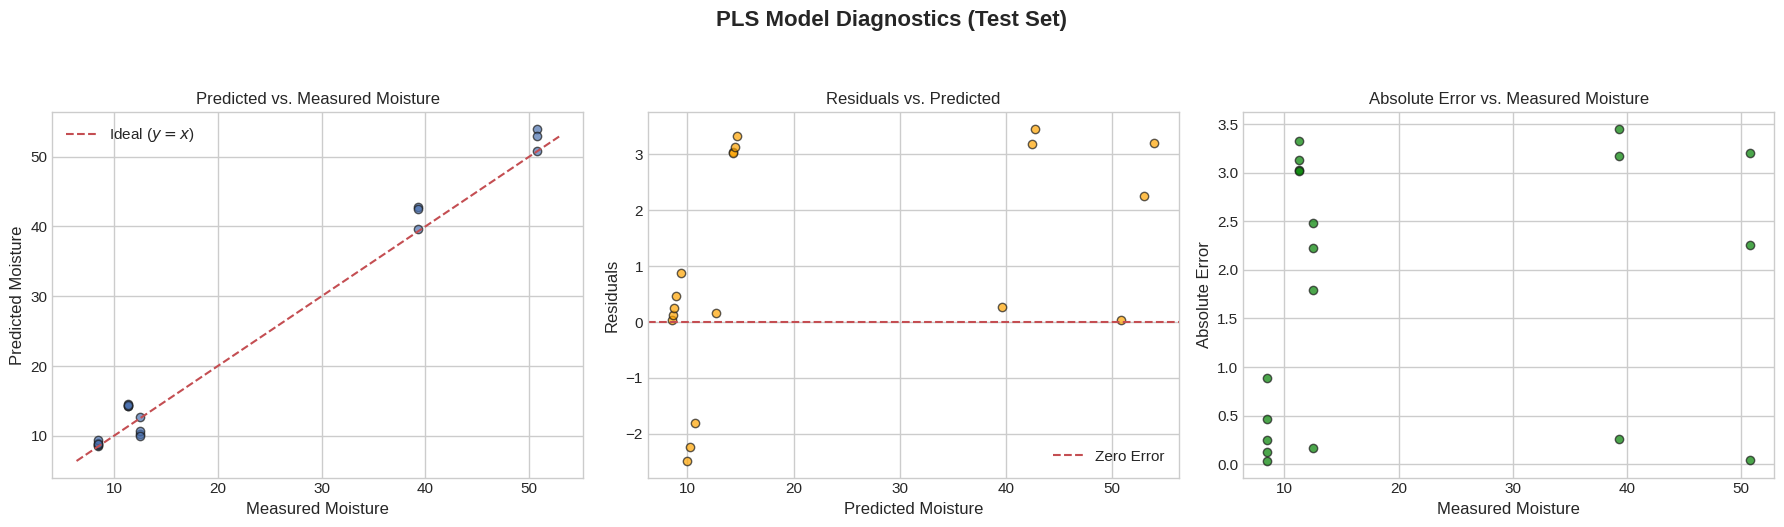

In [17]:
residuals_pls = y_pred_pls - y_test_flat
rmse_pls = np.sqrt(mean_squared_error(y_test_flat, y_pred_pls))
mae_pls = mean_absolute_error(y_test_flat, y_pred_pls)
r2_pls = r2_score(y_test_flat, y_pred_pls)
bias_pls = np.mean(residuals_pls)

pls_preds = pd.DataFrame({
    "Model": "PLS", "Sample": range(len(y_test_flat)),
    "Actual": y_test_flat, "Predicted": y_pred_pls,
    "Residual": residuals_pls, "Abs_Error": np.abs(residuals_pls),
})
pls_metrics = pd.DataFrame([{
    "Model": "PLS", "Type": "Metrics",
    "Latent_Variables": selected_components,
    "RMSECV": selected_rmsecv, "RMSE": rmse_pls,
    "MAE": mae_pls, "R2": r2_pls, "Mean_Bias": bias_pls,
}])
pd.concat([pls_preds, pls_metrics], ignore_index=True).to_csv(
    "outputs/results/model_results.csv", index=False)

print(f"--- PLS Test Performance ---")
print(f"Latent Variables: {selected_components}")
print(f"RMSECV: {selected_rmsecv:.4f}")
print(f"RMSE: {rmse_pls:.4f}, \nMAE: {mae_pls:.4f}, \nR²: {r2_pls:.4f}, \nBias: {bias_pls:.4f}")

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PLS Model Diagnostics (Test Set)", fontsize=16, fontweight="bold", y=1.05)
pad = (y_test_flat.max() - y_test_flat.min()) * 0.05
lims = [y_test_flat.min() - pad, y_test_flat.max() + pad]
axes[0].scatter(y_test_flat, y_pred_pls, alpha=0.7, edgecolor="k")
axes[0].plot(lims, lims, "r--", label="Ideal ($y=x$)")
axes[0].set_title("Predicted vs. Measured Moisture")
axes[0].set_xlabel("Measured Moisture")
axes[0].set_ylabel("Predicted Moisture")
axes[0].legend()

axes[1].scatter(y_pred_pls, residuals_pls, alpha=0.7, edgecolor="k", color="orange")
axes[1].axhline(0, color="r", linestyle="--", label="Zero Error")
axes[1].set_title("Residuals vs. Predicted")
axes[1].set_xlabel("Predicted Moisture")
axes[1].set_ylabel("Residuals")
axes[1].legend()

axes[2].scatter(y_test_flat, np.abs(residuals_pls), alpha=0.7, edgecolor="k", color="green")
axes[2].set_title("Absolute Error vs. Measured Moisture")
axes[2].set_xlabel("Measured Moisture")
axes[2].set_ylabel("Absolute Error")
plt.tight_layout()
fig.savefig("outputs/figures/pls_model_diagnostics.svg", format="svg", bbox_inches="tight")
plt.show()

# 18. Random Forest Training and Evaluation

Trains a Random Forest Regressor on the training data, computes test set performance metrics, appends the results to the metrics CSV file, and generates diagnostic plots for predicted values, residuals, and absolute errors.

--- Random Forest Test Performance ---
N Estimators: 500, Max Depth: 10
RMSE: 1.4011, 
MAE: 1.2307, 
R²: 0.9927, 
Bias: 0.9898


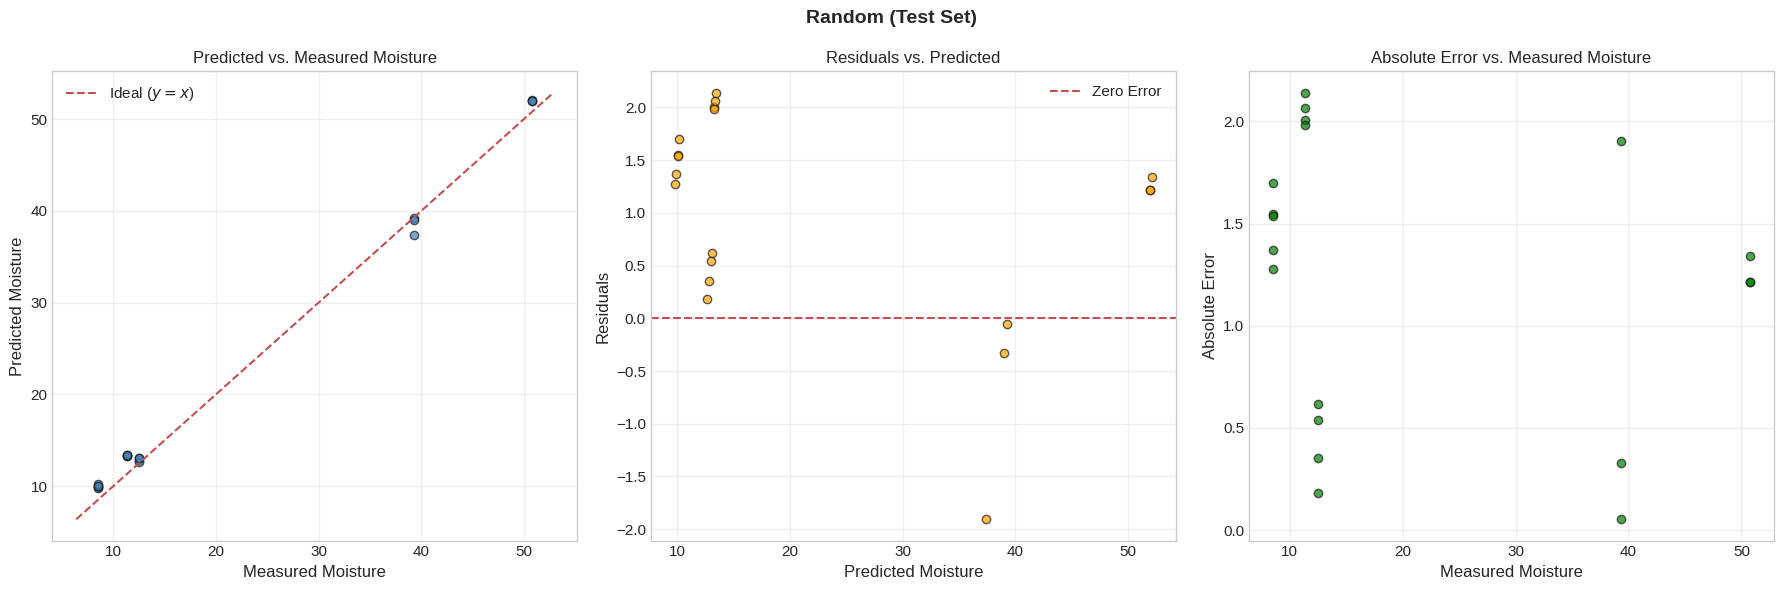

In [22]:
rf = RandomForestRegressor(n_estimators=500, max_features='sqrt', max_depth=10, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

y_test = np.asarray(y_test).squeeze()
y_pred_rf = np.asarray(y_pred_rf).squeeze()

residuals_rf = y_pred_rf - y_test
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
bias_rf = np.mean(residuals_rf)

rf_preds = pd.DataFrame({
    "Model": "RandomForest", "Sample": range(len(y_test)),
    "Actual": y_test, "Predicted": y_pred_rf,
    "Residual": residuals_rf, "Abs_Error": np.abs(residuals_rf),
})
rf_metrics = pd.DataFrame([{
    "Model": "RandomForest", "Type": "Metrics",
    "N_Estimators": 500, "Max_Depth": 10,
    "RMSE": rmse_rf, "MAE": mae_rf,
    "R2": r2_rf, "Mean_Bias": bias_rf,
}])


os.makedirs("outputs/results", exist_ok=True)
prev_path = "outputs/results/model_results.csv"

if os.path.exists(prev_path):
    prev = pd.read_csv(prev_path)
    combined = pd.concat([prev, rf_preds, rf_metrics], ignore_index=True)
else:
    combined = pd.concat([rf_preds, rf_metrics], ignore_index=True)

combined.to_csv(prev_path, index=False)

print(f"--- Random Forest Test Performance ---")
print(f"N Estimators: 500, Max Depth: 10")
print(f"RMSE: {rmse_rf:.4f}, \nMAE: {mae_rf:.4f}, \nR²: {r2_rf:.4f}, \nBias: {bias_rf:.4f}")

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Random Forest Model Diagnostics (Test Set)", fontsize=14, fontweight="bold")

axes[0].scatter(y_test, y_pred_rf, alpha=0.7, edgecolor="k", color="steelblue")
pad = (y_test.max() - y_test.min()) * 0.05
lims = [y_test.min() - pad, y_test.max() + pad]
axes[0].plot(lims, lims, "r--", label="Ideal ($y = x$)")
axes[0].set_title("Predicted vs. Measured Moisture")
axes[0].set_xlabel("Measured Moisture")
axes[0].set_ylabel("Predicted Moisture")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.7, edgecolor="k", color="orange")
axes[1].axhline(0, color="r", linestyle="--", label="Zero Error")
axes[1].set_title("Residuals vs. Predicted")
axes[1].set_xlabel("Predicted Moisture")
axes[1].set_ylabel("Residuals")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].scatter(y_test, np.abs(residuals_rf), alpha=0.7, edgecolor="k", color="green")
axes[2].set_title("Absolute Error vs. Measured Moisture")
axes[2].set_xlabel("Measured Moisture")
axes[2].set_ylabel("Absolute Error")
axes[2].grid(alpha=0.3)

plt.tight_layout()
os.makedirs("outputs/figures", exist_ok=True)
fig.savefig("outputs/figures/rf_model_diagnostics.svg", format="svg", bbox_inches="tight")
plt.show()

# 19. Download Results
Run the cell below to zip and download the generated figures and results (`outputs/`) to your local machine. A browser pop-up will ask for confirmation before triggering the download.

In [23]:
should_download = output.eval_js('confirm("Do you want to download the generated outputs (figures & results)?");')

if should_download:
    output_dir = "outputs"
    zip_filename = "outputs.zip"

    if os.path.exists(output_dir) and os.listdir(output_dir):
        print("Zipping outputs directory...")
        os.system(f"zip -r -q {zip_filename} {output_dir}")

        print("Triggering download...")
        files.download(zip_filename)
    else:
        print("No files found in the 'outputs' directory to download.")
else:
    print("Download cancelled. Files remain in the Colab session storage.")

Zipping outputs directory...
Triggering download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>